# Product Metrics Analysis

This notebook analyzes the main product and business metrics of the Olist e-commerce platform.

The main goals are:
- to calculate core e-commerce metrics;
- to analyze their monthly dynamics;
- to evaluate customer purchasing behavior;
- to identify changes in product performance over time.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from etl.config import get_engine

engine = get_engine()

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

,database_name
0,olist_analytics


## 1. Overall Product Metrics

In [ ]:
query = """
SELECT
    COUNT(*) AS orders_count,

    COUNT(
        DISTINCT customer_unique_id
    ) AS customers_count,

    ROUND(
        SUM(order_items_value)::NUMERIC, 2
    ) AS gmv,

    ROUND(
        AVG(order_items_value)::NUMERIC, 2
    ) AS average_order_value,

    ROUND(
        AVG(items_count)::NUMERIC, 2
    ) AS average_items_per_order

FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL;
"""

overall_metrics = pd.read_sql(query, engine)
overall_metrics

,orders_count,customers_count,gmv,average_order_value,average_items_per_order
0,96478,93358,"15,419,773.75",159.83,1.14


In [4]:
calculated_aov = (
    overall_metrics.loc[0, "gmv"]
    / overall_metrics.loc[0, "orders_count"]
)

calculated_aov

np.float64(159.82683876116835)

In [5]:
overall_metrics.loc[0, "average_order_value"]

np.float64(159.83)

## 2. Monthly Product Metrics

In [7]:
query = """
SELECT
    order_month,

    COUNT(*) AS orders_count,

    COUNT(
        DISTINCT customer_unique_id
    ) AS customers_count,

    ROUND(
        SUM(order_items_value)::NUMERIC, 2
    ) AS gmv,

    ROUND(
        AVG(order_items_value)::NUMERIC, 2
    ) AS average_order_value,

    ROUND(
        AVG(items_count)::NUMERIC, 2
    ) AS average_items_per_order

FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL
GROUP BY order_month
ORDER BY order_month;
"""

monthly_metrics = pd.read_sql(query, engine)
monthly_metrics

,order_month,orders_count,customers_count,gmv,average_order_value,average_items_per_order
0,2016-09-01,1,1,143.46,143.46,3.00
1,2016-10-01,265,262,"46,490.66",175.44,1.18
2,2016-12-01,1,1,19.62,19.62,1.00
3,2017-01-01,750,718,"127,482.37",169.98,1.22
4,2017-02-01,1653,1630,"271,239.32",164.09,1.12
5,2017-03-01,2546,2508,"414,330.95",162.74,1.14
6,2017-04-01,2303,2274,"390,812.40",169.70,1.12
7,2017-05-01,3546,3479,"566,851.40",159.86,1.13
8,2017-06-01,3135,3076,"490,050.37",156.32,1.11
9,2017-07-01,3872,3802,"566,299.08",146.25,1.14


In [8]:
monthly_metrics.head()

,order_month,orders_count,customers_count,gmv,average_order_value,average_items_per_order
0,2016-09-01,1,1,143.46,143.46,3.00
1,2016-10-01,265,262,"46,490.66",175.44,1.18
2,2016-12-01,1,1,19.62,19.62,1.00
3,2017-01-01,750,718,"127,482.37",169.98,1.22
4,2017-02-01,1653,1630,"271,239.32",164.09,1.12


In [9]:
monthly_metrics.tail()

,order_month,orders_count,customers_count,gmv,average_order_value,average_items_per_order
18,2018-04-01,6798,6744,"1,132,878.93",166.65,1.15
19,2018-05-01,6749,6693,"1,128,774.52",167.25,1.16
20,2018-06-01,6099,6061,"1,011,978.29",165.93,1.15
21,2018-07-01,6159,6100,"1,027,807.28",166.88,1.13
22,2018-08-01,6351,6310,"985,491.64",155.17,1.12


In [11]:
monthly_metrics["order_month"] = pd.to_datetime(
    monthly_metrics["order_month"]
)

monthly_metrics_filtered = monthly_metrics[
    monthly_metrics["order_month"].between(
        "2017-01-01",
        "2018-08-01",
    )
].copy()

monthly_metrics_filtered

,order_month,orders_count,customers_count,gmv,average_order_value,average_items_per_order
3,2017-01-01,750,718,"127,482.37",169.98,1.22
4,2017-02-01,1653,1630,"271,239.32",164.09,1.12
5,2017-03-01,2546,2508,"414,330.95",162.74,1.14
6,2017-04-01,2303,2274,"390,812.40",169.70,1.12
7,2017-05-01,3546,3479,"566,851.40",159.86,1.13
8,2017-06-01,3135,3076,"490,050.37",156.32,1.11
9,2017-07-01,3872,3802,"566,299.08",146.25,1.14
10,2017-08-01,4193,4114,"645,832.36",154.03,1.14
11,2017-09-01,4150,4083,"701,077.49",168.93,1.14
12,2017-10-01,4478,4417,"751,117.01",167.73,1.16


### Monthly GMV

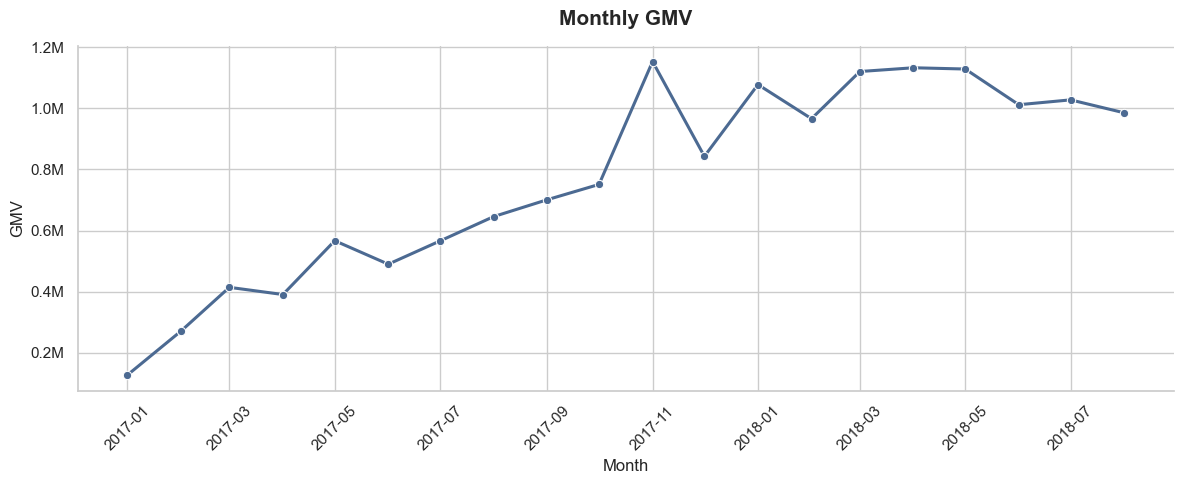

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_metrics_filtered,
    x="order_month",
    y="gmv",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly GMV",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("GMV")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value / 1_000_000:.1f}M"
    )
)

ax.tick_params(
    axis="x",
    rotation=45,
)

sns.despine()
plt.tight_layout()
plt.show()

### Monthly GMV findings

Monthly GMV increased substantially throughout 2017, rising from approximately 0.1 million in January to more than 1.1 million in November.

The strongest increase occurred in November 2017, which is consistent with the peak in monthly order volume observed during the EDA. This may reflect seasonal promotional activity, although the exact cause requires additional confirmation.

During 2018, GMV remained relatively stable at approximately 1.0–1.1 million per month. Compared with 2017, this indicates that the platform moved from a rapid growth phase to a more stable level of monthly sales.

Because GMV depends on both order volume and average order value, the next step is to analyze these two components separately.

### Monthly Number of Delivered Orders

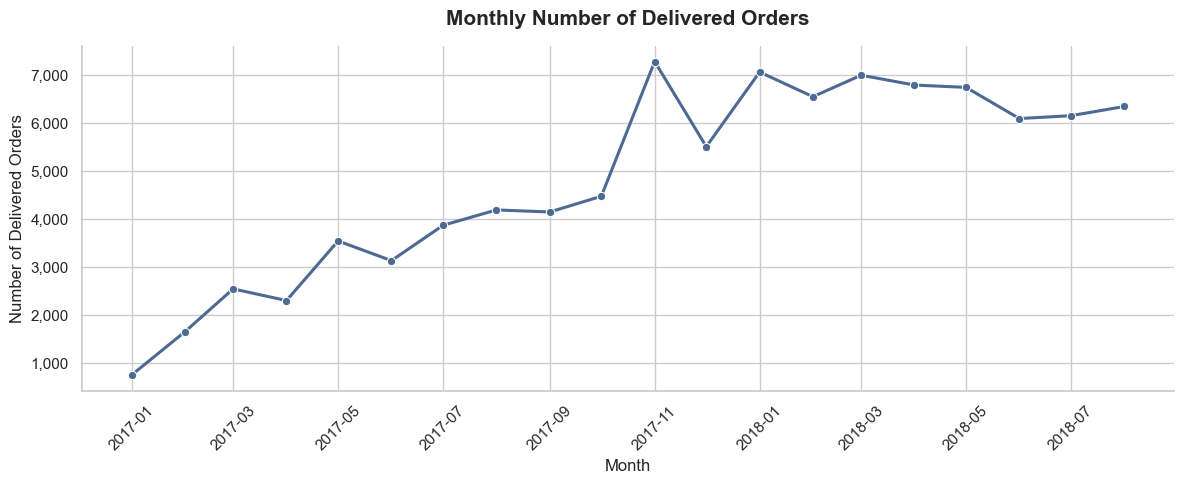

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_metrics_filtered,
    x="order_month",
    y="orders_count",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly Number of Delivered Orders",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Delivered Orders")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{int(value):,}"
    )
)

ax.tick_params(
    axis="x",
    rotation=45,
)

sns.despine()
plt.tight_layout()
plt.show()

### Monthly order volume findings

The number of delivered orders increased steadily throughout 2017, rising from fewer than 1,000 orders in January to more than 7,000 in November.

The monthly pattern is very similar to the GMV trend. This indicates that the growth in GMV was driven primarily by an increase in order volume rather than by a substantial change in average order value.

During most of 2018, the number of delivered orders remained relatively stable at approximately 6,000–7,000 per month, which is consistent with the stabilization observed in monthly GMV.

### Monthly Average Order Value

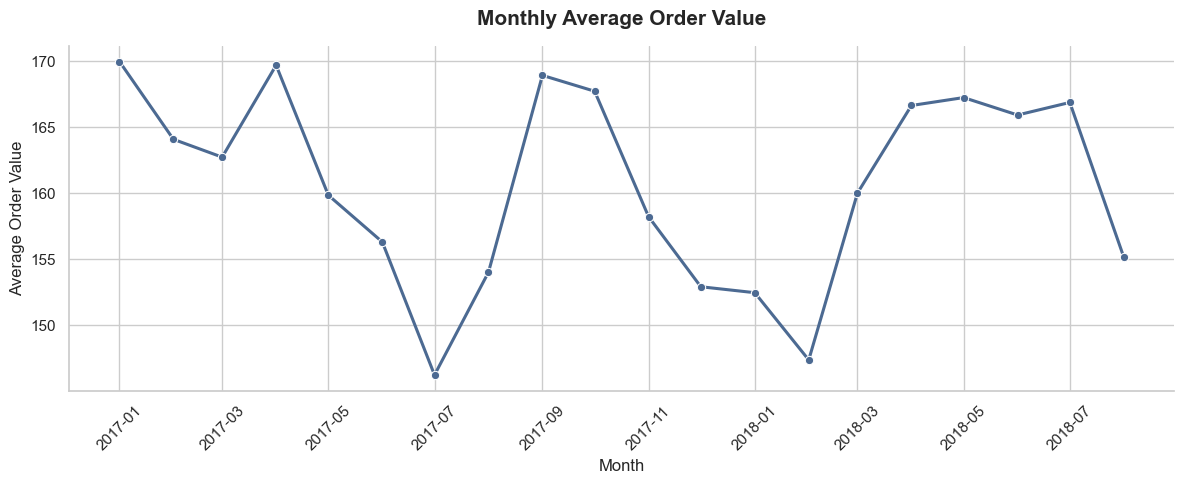

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_metrics_filtered,
    x="order_month",
    y="average_order_value",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly Average Order Value",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Average Order Value")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:,.0f}"
    )
)

ax.tick_params(
    axis="x",
    rotation=45,
)

sns.despine()
plt.tight_layout()
plt.show()

### Monthly average order value findings

Monthly average order value remained relatively stable throughout the analyzed period, generally ranging from approximately 150 to 170.

Unlike GMV and order volume, the average order value does not show a clear long-term upward trend. The lowest values appear around July 2017 and February 2018, while several months reach approximately 168–170.

This confirms that the substantial growth in GMV during 2017 was driven mainly by an increase in the number of delivered orders rather than by customers spending significantly more per order.

## 3. Customer Purchase Behavior

In [ ]:
query = """
SELECT
    customer_unique_id,
    COUNT(*) AS orders_count,
    ROUND(
        SUM(order_items_value)::NUMERIC, 2
    ) AS customer_gmv
FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL
GROUP BY customer_unique_id;
"""

customer_orders = pd.read_sql(query, engine)
customer_orders.head()

,customer_unique_id,orders_count,customer_gmv
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [16]:
customer_orders["orders_count"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count   93,358.00
mean         1.03
std          0.21
min          1.00
50%          1.00
75%          1.00
90%          1.00
95%          1.00
99%          2.00
max         15.00
Name: orders_count, dtype: float64

In [17]:
customer_summary = pd.DataFrame(
    {
        "customers_count": [
            customer_orders["customer_unique_id"].nunique()
        ],
        "repeat_customers_count": [
            (customer_orders["orders_count"] > 1).sum()
        ],
    }
)

customer_summary["repeat_customers_share_percent"] = (
    customer_summary["repeat_customers_count"]
    / customer_summary["customers_count"]
    * 100
)

customer_summary

,customers_count,repeat_customers_count,repeat_customers_share_percent
0,93358,2801,3.00


In [21]:
customer_orders["order_frequency_group"] = pd.cut(
    customer_orders["orders_count"],
    bins=[0, 1, 2, 3, 4, float("inf")],
    labels=[
        "1 order",
        "2 orders",
        "3 orders",
        "4 orders",
        "5+ orders",
    ],
)

frequency_distribution = (
    customer_orders
    .groupby(
        "order_frequency_group",
        observed=False,
    )
    .agg(
        customers_count=(
            "customer_unique_id",
            "count",
        )
    )
    .reset_index()
)

frequency_distribution["customers_share_percent"] = (
    frequency_distribution["customers_count"]
    / frequency_distribution["customers_count"].sum()
    * 100
)

frequency_distribution

,order_frequency_group,customers_count,customers_share_percent
0,1 order,90557,97.00
1,2 orders,2573,2.76
2,3 orders,181,0.19
3,4 orders,28,0.03
4,5+ orders,19,0.02


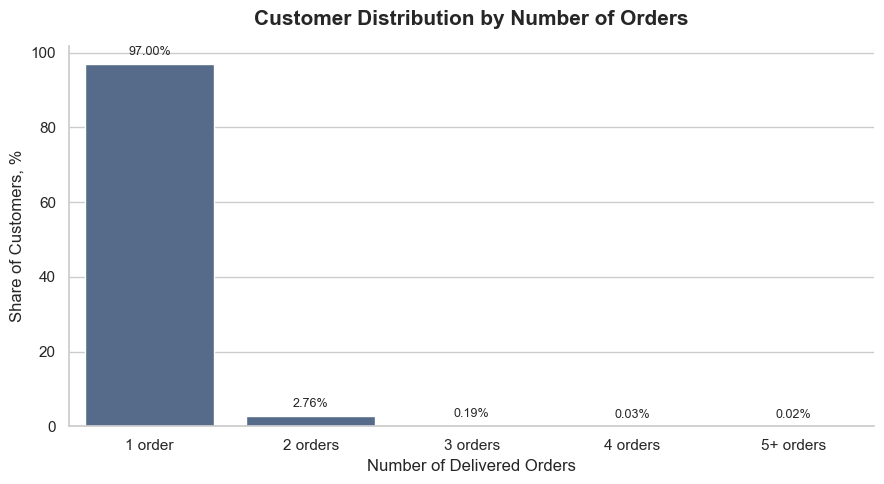

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=frequency_distribution,
    x="order_frequency_group",
    y="customers_share_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Customer Distribution by Number of Orders",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Number of Delivered Orders")
ax.set_ylabel("Share of Customers, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Customer purchase frequency findings

Customer purchase frequency is extremely low.

Approximately 97% of customers made only one delivered order during the entire observation period. Only about 2.76% placed two orders, while customers with three or more orders account for less than 0.25% of the customer base.

This indicates that the platform relied primarily on one-time purchases rather than repeat customer activity. As a result, customer retention is likely to be one of the main areas for further analysis.

However, this metric is calculated over the full available period and does not account for differences in customer acquisition dates. Customers acquired near the end of the dataset had less time to make a repeat purchase. A cohort analysis is therefore required for a more accurate retention assessment.

## 4. Monthly Customer Activity

### Monthly Number of Active Customers

In [23]:
query = """
SELECT
    order_month,
    COUNT(
        DISTINCT customer_unique_id
    ) AS customers_count
FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL
GROUP BY order_month
ORDER BY order_month;
"""

monthly_customers = pd.read_sql(query, engine)

monthly_customers["order_month"] = pd.to_datetime(
    monthly_customers["order_month"]
)

monthly_customers_filtered = monthly_customers[
    monthly_customers["order_month"].between(
        "2017-01-01",
        "2018-08-01",
    )
].copy()

monthly_customers_filtered

,order_month,customers_count
3,2017-01-01,718
4,2017-02-01,1630
5,2017-03-01,2508
6,2017-04-01,2274
7,2017-05-01,3479
8,2017-06-01,3076
9,2017-07-01,3802
10,2017-08-01,4114
11,2017-09-01,4083
12,2017-10-01,4417


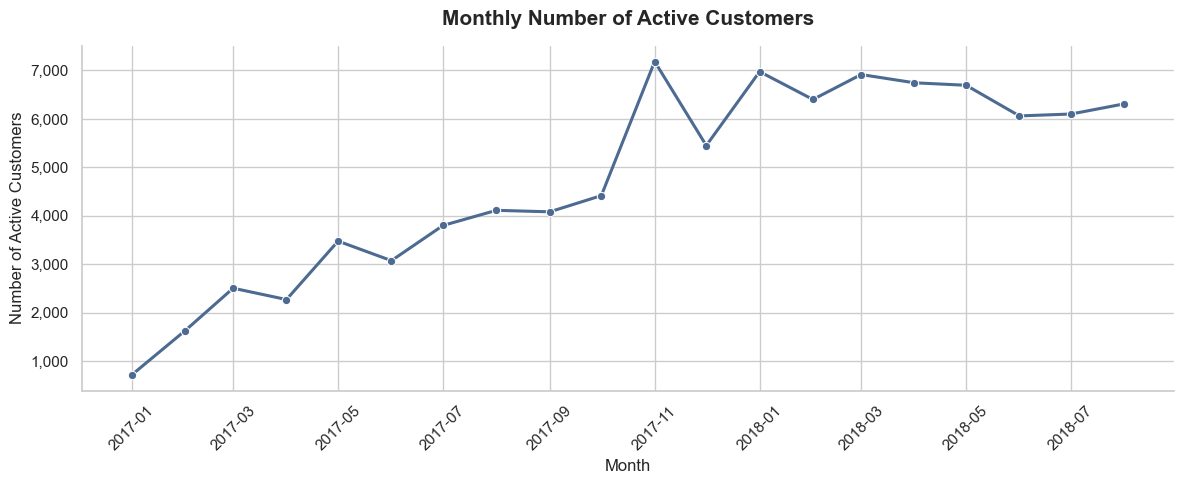

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_customers_filtered,
    x="order_month",
    y="customers_count",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly Number of Active Customers",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Active Customers")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{int(value):,}"
    )
)

ax.tick_params(
    axis="x",
    rotation=45,
)

sns.despine()
plt.tight_layout()
plt.show()

### Monthly active customer findings

The number of active customers increased substantially throughout 2017, rising from fewer than 1,000 customers in January to more than 7,000 in November.

The trend closely follows the dynamics of delivered orders and GMV. This is consistent with the earlier finding that most customers place only one order: monthly business growth was driven primarily by attracting more customers rather than by increasing purchase frequency among existing customers.

During most of 2018, the number of active customers remained relatively stable at approximately 6,000–7,000 per month, indicating that customer activity reached a more stable level after the rapid growth observed in 2017.

### Monthly Share of Repeat Customers

In [25]:
query = """
WITH delivered_orders AS (
    SELECT
        customer_unique_id,
        order_month
    FROM analytics.order_metrics
    WHERE order_status = 'delivered'
      AND order_items_value IS NOT NULL
),
first_purchase AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS first_order_month
    FROM delivered_orders
    GROUP BY customer_unique_id
),
monthly_customer_types AS (
    SELECT DISTINCT
        d.order_month,
        d.customer_unique_id,
        CASE
            WHEN d.order_month = f.first_order_month
                THEN 'New'
            ELSE 'Repeat'
        END AS customer_type
    FROM delivered_orders AS d
    JOIN first_purchase AS f
        ON d.customer_unique_id = f.customer_unique_id
)
SELECT
    order_month,
    customer_type,
    COUNT(*) AS customers_count
FROM monthly_customer_types
GROUP BY
    order_month,
    customer_type
ORDER BY
    order_month,
    customer_type;
"""

monthly_customer_types = pd.read_sql(query, engine)

monthly_customer_types["order_month"] = pd.to_datetime(
    monthly_customer_types["order_month"]
)

monthly_customer_types_filtered = monthly_customer_types[
    monthly_customer_types["order_month"].between(
        "2017-01-01",
        "2018-08-01",
    )
].copy()

monthly_customer_types_filtered.head()

,order_month,customer_type,customers_count
3,2017-01-01,New,717
4,2017-01-01,Repeat,1
5,2017-02-01,New,1628
6,2017-02-01,Repeat,2
7,2017-03-01,New,2503


In [26]:
monthly_customer_pivot = (
    monthly_customer_types_filtered
    .pivot(
        index="order_month",
        columns="customer_type",
        values="customers_count",
    )
    .fillna(0)
    .reset_index()
)

monthly_customer_pivot["total_customers"] = (
    monthly_customer_pivot["New"]
    + monthly_customer_pivot["Repeat"]
)

monthly_customer_pivot["repeat_share_percent"] = (
    monthly_customer_pivot["Repeat"]
    / monthly_customer_pivot["total_customers"]
    * 100
)

monthly_customer_pivot

customer_type,order_month,New,Repeat,total_customers,repeat_share_percent
0,2017-01-01,717,1,718,0.14
1,2017-02-01,1628,2,1630,0.12
2,2017-03-01,2503,5,2508,0.20
3,2017-04-01,2256,18,2274,0.79
4,2017-05-01,3451,28,3479,0.80
5,2017-06-01,3037,39,3076,1.27
6,2017-07-01,3752,50,3802,1.32
7,2017-08-01,4057,57,4114,1.39
8,2017-09-01,4004,79,4083,1.93
9,2017-10-01,4328,89,4417,2.01


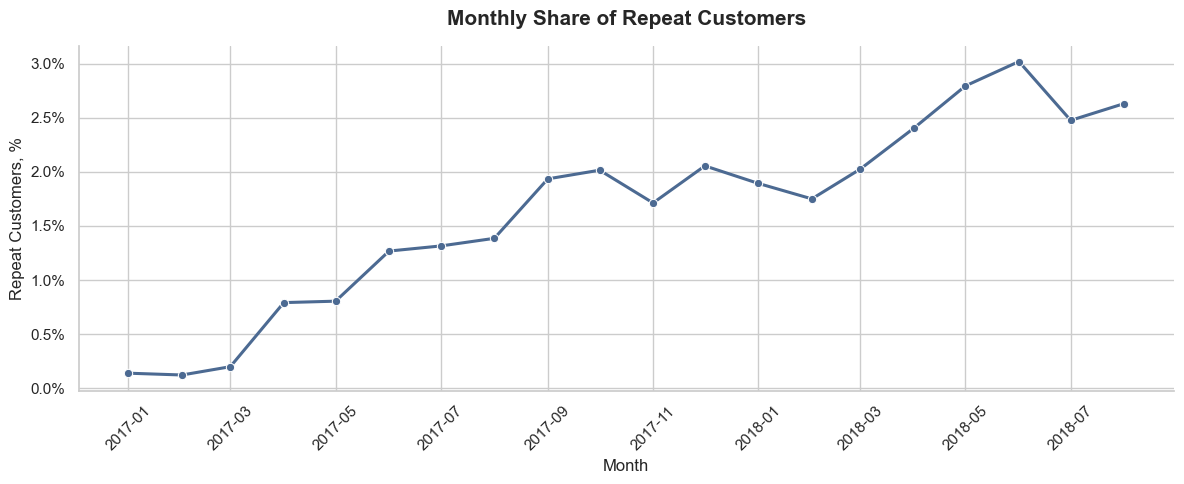

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_customer_pivot,
    x="order_month",
    y="repeat_share_percent",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly Share of Repeat Customers",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Repeat Customers, %")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.1f}%"
    )
)

sns.despine()
plt.tight_layout()
plt.show()

### Monthly repeat customer findings

The share of repeat customers increased gradually over time, from below 0.5% in early 2017 to approximately 2.5–3.0% by the middle of 2018.

This suggests that repeat purchase activity improved as the platform matured. However, even at its highest point, repeat customers represented only a small share of monthly active customers.

The result is consistent with the overall purchase frequency distribution, where the vast majority of customers placed only one order. Therefore, customer acquisition remained the main source of monthly activity, while repeat purchasing played a limited but gradually increasing role.

## 5. Items per order

In [28]:
monthly_items = monthly_metrics_filtered[
    [
        "order_month",
        "average_items_per_order",
    ]
].copy()

monthly_items

,order_month,average_items_per_order
3,2017-01-01,1.22
4,2017-02-01,1.12
5,2017-03-01,1.14
6,2017-04-01,1.12
7,2017-05-01,1.13
8,2017-06-01,1.11
9,2017-07-01,1.14
10,2017-08-01,1.14
11,2017-09-01,1.14
12,2017-10-01,1.16


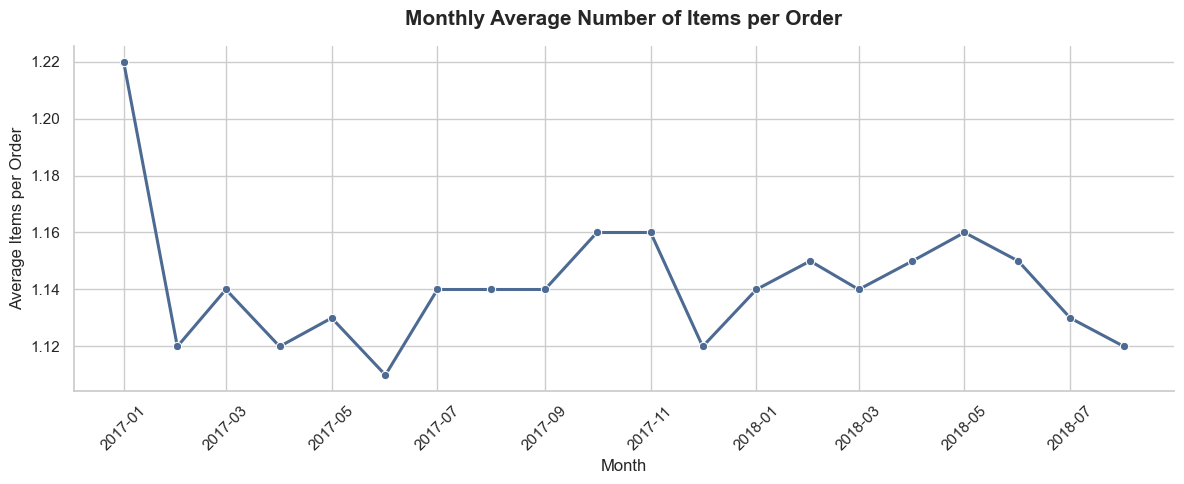

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_items,
    x="order_month",
    y="average_items_per_order",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly Average Number of Items per Order",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Average Items per Order")

ax.tick_params(
    axis="x",
    rotation=45,
)

sns.despine()
plt.tight_layout()
plt.show()

### Items per order findings

The average number of items per order remained very stable throughout the analyzed period.

In most months, customers purchased approximately 1.12–1.16 items per order. January 2017 stands out with a slightly higher value of about 1.22, but this does not develop into a persistent trend.

This suggests that customers usually place small orders containing only one item. The growth in GMV was therefore not driven by larger baskets, but mainly by a higher number of customers and orders.

## 6. Key Findings

### Overall product metrics findings

1. Monthly GMV grew rapidly during 2017 and stabilized at approximately 1.0–1.1 million per month during most of 2018.

2. The growth in GMV was driven primarily by an increase in the number of delivered orders and active customers.

3. Average order value remained relatively stable, generally ranging from approximately 150 to 170.

4. The average number of items per order also remained stable at around 1.1–1.2, indicating that customers typically purchased only one item per order.

5. Customer purchase frequency is very low: approximately 97% of customers placed only one delivered order during the observation period.

6. The monthly share of repeat customers gradually increased, but remained below approximately 3%.

7. Overall, the platform’s growth was based mainly on customer acquisition rather than on higher spending, larger baskets, or frequent repeat purchases.

### Product hypotheses

- Improving repeat purchase behavior may offer a significant growth opportunity.
- Cross-selling and product recommendations may help increase the number of items per order.
- Personalized promotions may increase average order value among existing customers.
- Retention may differ substantially across customer cohorts, categories, and regions.

In [30]:
engine.dispose()